# 22 - MaxViT Real + Augmented + Synthetic From-Scratch SD-VAE

Training MaxViT-Tiny-512 su dati reali, augmentation tradizionale positiva e sintetiche prodotte dal diffusore from scratch con VAE Stable Diffusion (`data/synthetic/fromscratch_new`).


In [2]:
# === Bootstrap unificato notebooks/ ===
# Funziona dalla root del progetto e da ogni sottocartella della struttura notebooks/.
import sys as _sys
from pathlib import Path as _Path


def _find_mammo_root():
    for _candidate in [_Path.cwd().resolve(), *_Path.cwd().resolve().parents]:
        if _candidate.name == "MammoDiffusion":
            return _candidate
        if (_candidate / "data").is_dir() and (_candidate / "notebooks").is_dir():
            return _candidate
    raise FileNotFoundError("Root MammoDiffusion non trovata da " + str(_Path.cwd()))


PROJECT_ROOT = _find_mammo_root()
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
UTILITY_DIR = NOTEBOOKS_DIR / "utility"
for _path in (str(UTILITY_DIR), str(NOTEBOOKS_DIR)):
    if _path not in _sys.path:
        _sys.path.insert(0, _path)

BASE = PROJECT_ROOT
BASE_DIR = PROJECT_ROOT
BASE_PATH = str(PROJECT_ROOT) + "/"
# === Fine bootstrap unificato ===

import os

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-9a95e5e1-599d-6315-52fb-b6a602960eb8"  # RTX 3060
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"

print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))

CUDA_VISIBLE_DEVICES: GPU-9a95e5e1-599d-6315-52fb-b6a602960eb8


In [3]:
import tensorflow as tf
from tensorflow.python.client import device_lib

print(tf.config.list_physical_devices("GPU"))

for d in device_lib.list_local_devices():
    if d.device_type == "GPU":
        print(d.physical_device_desc)

2026-07-05 22:42:38.647526: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-05 22:42:38.647561: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-05 22:42:38.648502: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-05 22:42:38.653603: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-05 22:42:39.222267: W tensorflow/compiler/tf2

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:04:00.0, compute capability: 8.6


2026-07-05 22:42:40.119730: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-05 22:42:40.161208: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-05 22:42:40.166017: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [4]:
import os
import sys
from pathlib import Path

# [notebooks bootstrap] Il blocco Colab/local originale e' stato
# neutralizzato: BASE_PATH e' gia' definito dal bootstrap unificato in cima.

BASE = Path(BASE_PATH).resolve()
print("Percorso base:", BASE)


Ambiente locale rilevato.
Percorso base: /home/fede/Documenti/MammoDiffusion


In [5]:
import json
import zipfile
import re
from datetime import date
from pathlib import Path

import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

sys.path.insert(0, os.getcwd())
from maxvit_utils import (
    build_maxvit_model,
    resolve_normalization,
    make_dataloader,
    freeze_all,
    unfreeze_head,
    unfreeze_stages_from,
    unfreeze_all,
    count_trainable_params,
    BinaryFocalLoss,
    compute_pos_weight,
    EarlyStopping,
    ModelCheckpoint,
    CSVLogger,
    fit,
    predict_probs,
    optimal_threshold_youden,
    bootstrap_balanced,
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)


Device: cuda


In [6]:
PROCESSED_DRIVE_ID = "1qQral_BIBlMl0QN3PllJukdYTOmNGWr3"
PROCESSED_ZIP = BASE / 'data' / 'processed' / 'processed.zip'

TRAIN_CSV_PATH = BASE / 'data' / 'processed' / 'metadata' / 'train.csv'
VAL_CSV_PATH = BASE / 'data' / 'processed' / 'metadata' / 'val.csv'
TEST_CSV_PATH = BASE / 'data' / 'processed' / 'metadata' / 'test.csv'

def processed_data_ready():
    required = [
        TRAIN_CSV_PATH,
        VAL_CSV_PATH,
        TEST_CSV_PATH,
        BASE / 'data' / 'processed' / 'train' / '0',
        BASE / 'data' / 'processed' / 'train' / '1',
        BASE / 'data' / 'processed' / 'val' / '0',
        BASE / 'data' / 'processed' / 'val' / '1',
    ]
    return all(p.exists() for p in required)

if not processed_data_ready():
    print("Dataset preprocessato non trovato, scarico da Google Drive...")
    PROCESSED_ZIP.parent.mkdir(parents=True, exist_ok=True)
    gdown.download(id=PROCESSED_DRIVE_ID, output=str(PROCESSED_ZIP), quiet=False)
    with zipfile.ZipFile(PROCESSED_ZIP, 'r') as z:
        z.extractall(BASE / 'data' / 'processed')
    PROCESSED_ZIP.unlink(missing_ok=True)
    print("Dataset estratto in:", BASE / 'data' / 'processed')
else:
    print("Dataset preprocessato gia presente.")


Dataset preprocessato gia presente.


In [7]:
SYNTH_ROOT = BASE / 'data' / 'synthetic' / 'fromscratch_new'
SYNTHETIC_SOURCE_NAME = 'FromScratch_SD_VAE'
FINE_TUNE_MODE = 'partial'  # cambia in 'full' dopo il confronto 15b, se la validation lo suggerisce

EXPERIMENT_BASE = 'classifiers/maxvit512/02i_real_aug_synth_fromscratch'
OUTPUT_DIR = BASE / 'experiments' / f'{EXPERIMENT_BASE}_{FINE_TUNE_MODE}'
OUTPUT_CSV = BASE / 'data' / 'synthetic' / 'metadata' / 'train_real_augmented_synthetic_fromscratch_sdvae.csv'
CHECKPOINT_PREFIX = f'real_aug_synth_fromscratch_sdvae_maxvit512_{FINE_TUNE_MODE}'

print("Sorgente sintetica:", SYNTHETIC_SOURCE_NAME)
print("Cartella sintetiche:", SYNTH_ROOT)
print("Esperimento:", OUTPUT_DIR)


Sorgente sintetica: FromScratch_SD_VAE
Cartella sintetiche: /home/fede/Documenti/MammoDiffusion/data/synthetic/fromscratch_new
Esperimento: /home/fede/Documenti/MammoDiffusion/experiments/exp_maxvit512_real_aug_synth_fromscratch_sdvae_partial


In [8]:
IMAGE_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}

def image_paths(directory):
    directory = Path(directory)
    return sorted(
        p for p in directory.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS and not p.name.startswith('.')
    )

def load_real_split(split):
    rows = []
    split_dir = BASE / 'data' / 'processed' / split
    for label in [0, 1]:
        for path in image_paths(split_dir / str(label)):
            rows.append({
                'processed_path': str(path),
                'cancer': label,
                'source': 'real',
                'source_detail': f'real_{split}',
            })
    df = pd.DataFrame(rows)
    if df.empty:
        raise FileNotFoundError(f"Nessuna immagine reale trovata in {split_dir}")
    return df

def load_synthetic_both(root, source_name):
    root = Path(root)
    rows = []
    for folder, label in [('negative', 0), ('positive', 1)]:
        folder_path = root / folder
        paths = image_paths(folder_path) if folder_path.is_dir() else []
        if not paths:
            raise FileNotFoundError(
                f"Nessuna immagine sintetica {folder} in {folder_path}. "
                "Esegui prima il notebook generativo corrispondente."
            )
        for path in paths:
            rows.append({
                'processed_path': str(path),
                'cancer': label,
                'source': 'synthetic',
                'source_detail': source_name,
            })
    return pd.DataFrame(rows)

_LABEL_RE = re.compile(r"_label([01])")

def load_augmented_positive():
    aug_dir = BASE / 'data' / 'real_augmented'
    rows = []
    if not aug_dir.is_dir():
        raise FileNotFoundError(
            f"Cartella {aug_dir} mancante. Esegui prima 02_Data_Augmentation_Trad.ipynb."
        )
    for path in image_paths(aug_dir):
        match = _LABEL_RE.search(path.name)
        if match is None:
            continue
        rows.append({
            'processed_path': str(path),
            'cancer': int(match.group(1)),
            'source': 'augmented',
            'source_detail': 'traditional_positive_augmentation',
        })
    df = pd.DataFrame(rows)
    if df.empty:
        raise FileNotFoundError(f"Nessuna immagine augmentata riconosciuta in {aug_dir}")
    return df

def print_counts(name, df):
    labels = df['cancer'].astype(int)
    print(
        f"{name:18s} tot={len(df):5d} | sano(0)={(labels == 0).sum():5d} | "
        f"malato(1)={(labels == 1).sum():5d}"
    )

def source_table(df):
    table = pd.crosstab(df['source_detail'], df['cancer'])
    table = table.rename(columns={0: 'sano_0', 1: 'malato_1'})
    table['totale'] = table.sum(axis=1)
    return table


In [9]:
df_real_train = load_real_split('train')
df_aug = load_augmented_positive()
df_synth = load_synthetic_both(SYNTH_ROOT, SYNTHETIC_SOURCE_NAME)
df_val = load_real_split('val')
df_test = load_real_split('test')

df_train = pd.concat([df_real_train, df_aug, df_synth], ignore_index=True)
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
df_train.to_csv(OUTPUT_CSV, index=False)

print("CSV training combinato salvato in:", OUTPUT_CSV)
print_counts("REAL train", df_real_train)
print_counts("AUG train", df_aug)
print_counts("SYN train", df_synth)
print_counts("TRAIN total", df_train)
print_counts("VAL real", df_val)
print_counts("TEST real", df_test)
display(source_table(df_train))


CSV training combinato salvato in: /home/fede/Documenti/MammoDiffusion/data/synthetic/metadata/train_real_augmented_synthetic_fromscratch_sdvae.csv
REAL train         tot= 2041 | sano(0)= 1701 | malato(1)=  340
AUG train          tot= 1020 | sano(0)=    0 | malato(1)= 1020
SYN train          tot= 2722 | sano(0)= 1361 | malato(1)= 1361
TRAIN total        tot= 5783 | sano(0)= 3062 | malato(1)= 2721
VAL real           tot=  437 | sano(0)=  364 | malato(1)=   73
TEST real          tot=  438 | sano(0)=  365 | malato(1)=   73


cancer,sano_0,malato_1,totale
source_detail,,,
FromScratch_SD_VAE,1361,1361,2722
real_train,1701,340,2041
traditional_positive_augmentation,0,1020,1020


In [10]:
IMG_SIZE = 512
BATCH_SIZE = 8
SEED = 42
IMAGENET_MEAN = (0.5, 0.5, 0.5)
IMAGENET_STD = (0.5, 0.5, 0.5)

torch.manual_seed(SEED)
np.random.seed(SEED)

def make_loaders(df_train, df_val, df_test=None):
    train_loader = make_dataloader(
        df_train, 'processed_path', 'cancer', IMAGENET_MEAN, IMAGENET_STD, IMG_SIZE,
        batch_size=BATCH_SIZE, shuffle=True, augment=False, seed=SEED,
    )
    val_loader = make_dataloader(
        df_val, 'processed_path', 'cancer', IMAGENET_MEAN, IMAGENET_STD, IMG_SIZE,
        batch_size=BATCH_SIZE, shuffle=False,
    )
    test_loader = None
    if df_test is not None:
        test_loader = make_dataloader(
            df_test, 'processed_path', 'cancer', IMAGENET_MEAN, IMAGENET_STD, IMG_SIZE,
            batch_size=BATCH_SIZE, shuffle=False,
        )
    return train_loader, val_loader, test_loader

def apply_fine_tune_mode(model, fine_tune_mode):
    if fine_tune_mode == 'partial':
        unfreeze_stages_from(model, start_stage=3)
        return "stage 3/4 (ultimo stage)"
    if fine_tune_mode == 'full':
        unfreeze_all(model)
        return "tutti gli stage"
    raise ValueError(f"fine_tune_mode non supportato: {fine_tune_mode}")

def plot_training_history(history, title_suffix, save_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    ax1.set_title(f'Loss {title_suffix}')
    ax1.set_xlabel('Epoca')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    ax2.plot(history.history['auc'], label='Train AUC', linewidth=2)
    ax2.plot(history.history['val_auc'], label='Val AUC', linewidth=2)
    ax2.set_title(f'AUC {title_suffix}')
    ax2.set_xlabel('Epoca')
    ax2.set_ylabel('AUC')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)

    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print("Grafico salvato in:", save_path)

def metrics_from_probs(y_true, y_prob, threshold, split, experiment_name, config_name):
    y_pred = (y_prob >= threshold).astype(int)
    report = classification_report(y_true, y_pred, target_names=['Sano', 'Malato'])
    return {
        'arch': 'MaxViT-Tiny-512',
        'config': config_name,
        'split': split,
        'experiment_name': experiment_name,
        'threshold_youden_from_val': round(float(threshold), 4),
        'roc_auc': round(float(roc_auc_score(y_true, y_prob)), 4),
        'accuracy': round(float((y_pred == y_true).mean()), 4),
        'precision_malato': round(float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
        'recall_malato': round(float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
        'f1_malato': round(float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
        'classification_report': report,
    }, y_pred

def save_confusion_roc(y_true, y_prob, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].imshow(cm, cmap='Blues')
    ax[0].set_xticks([0, 1]); ax[0].set_yticks([0, 1])
    ax[0].set_xticklabels(['Sano', 'Malato'])
    ax[0].set_yticklabels(['Sano', 'Malato'])
    ax[0].set_xlabel('Predetto'); ax[0].set_ylabel('Reale')
    ax[0].set_title('Confusion Matrix')
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax[0].text(j, i, cm[i, j], ha='center', va='center',
                       fontsize=14, fontweight='bold', color=color)
    ax[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc:.4f}')
    ax[1].plot([0, 1], [0, 1], '--', color='gray')
    ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR')
    ax[1].set_title('ROC')
    ax[1].legend()
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print("Figura salvata in:", save_path)

def train_maxvit_experiment(df_train, df_val, output_dir, checkpoint_prefix, config_name, fine_tune_mode):
    output_dir = Path(output_dir)
    figures_dir = output_dir / 'figures'
    output_dir.mkdir(parents=True, exist_ok=True)
    figures_dir.mkdir(parents=True, exist_ok=True)

    train_loader, val_loader, _ = make_loaders(df_train, df_val)

    model = build_maxvit_model(num_classes=1, pretrained=True)
    model.to(DEVICE)
    resolved_mean, resolved_std, resolved_size = resolve_normalization(model)
    assert resolved_size == IMG_SIZE, f"IMG_SIZE atteso {resolved_size}, trovato {IMG_SIZE}"
    print(f"Normalizzazione modello: mean={resolved_mean} std={resolved_std} input_size={resolved_size}")

    experiment_config = {
        'experiment_name': output_dir.name,
        'date': date.today().isoformat(),
        'config': config_name,
        'fine_tune_mode': fine_tune_mode,
        'backbone': {
            'name': 'maxvit_tiny_tf_512.in1k',
            'library': 'timm',
            'weights': 'in1k',
            'input_shape': [IMG_SIZE, IMG_SIZE, 3],
        },
        'data': {
            'batch_size': BATCH_SIZE,
            'seed': SEED,
            'n_train': int(len(df_train)),
            'n_val': int(len(df_val)),
            'source_counts': source_table(df_train).to_dict(orient='index'),
        },
        'phase1_head_training': {
            'optimizer': 'Adam',
            'learning_rate': 1e-3,
            'loss': 'BCEWithLogitsLoss(pos_weight=balanced)',
            'max_epochs': 25,
            'early_stopping_patience': 7,
            'backbone_trainable': False,
        },
        'phase2_fine_tuning': {
            'optimizer': 'Adam',
            'learning_rate': 1e-5,
            'loss': 'BinaryFocalLoss(alpha=0.75, gamma=2.0)',
            'max_epochs': 30,
            'fine_tune_from': fine_tune_mode,
            'early_stopping_patience': 5,
            'early_stopping_min_delta': 1e-3,
        },
    }
    with open(output_dir / 'experiment_config.json', 'w') as f:
        json.dump(experiment_config, f, indent=2, ensure_ascii=False)

    freeze_all(model)
    unfreeze_head(model)
    trainable, total = count_trainable_params(model)
    print(f"Parametri trainable (Fase 1): {trainable:,} / {total:,}")

    pos_weight = compute_pos_weight(df_train['cancer'].values).to(DEVICE)
    criterion_fase1 = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer_fase1 = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-3)
    history_phase1 = fit(
        model, train_loader, val_loader, optimizer_fase1, criterion_fase1,
        epochs=25, device=DEVICE,
        early_stopping=EarlyStopping(patience=7, mode='max', restore_best_weights=True),
        checkpoint=ModelCheckpoint(str(output_dir / f'{checkpoint_prefix}_fase1_best.pt'), mode='max'),
        csv_logger=CSVLogger(str(output_dir / 'training_log_fase1.csv')),
    )

    fine_tune_desc = apply_fine_tune_mode(model, fine_tune_mode)
    trainable, total = count_trainable_params(model)
    print(f"Parametri trainable (Fase 2 - {fine_tune_desc}): {trainable:,} / {total:,}")

    criterion_fase2 = BinaryFocalLoss(alpha=0.75, gamma=2.0)
    optimizer_fase2 = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-5)
    lr_scheduler_fase2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_fase2, mode='max', factor=0.5, patience=3, min_lr=1e-7
    )
    final_ckpt = output_dir / f'{checkpoint_prefix}_final_best.pt'
    history_phase2 = fit(
        model, train_loader, val_loader, optimizer_fase2, criterion_fase2,
        epochs=30, device=DEVICE,
        early_stopping=EarlyStopping(patience=5, min_delta=1e-3, mode='max', restore_best_weights=True),
        checkpoint=ModelCheckpoint(str(final_ckpt), mode='max'),
        csv_logger=CSVLogger(str(output_dir / 'training_log_fase2.csv')),
        lr_scheduler=lr_scheduler_fase2,
    )

    plot_training_history(history_phase1, '(Fase 1)', figures_dir / 'training_history_fase1.png')
    plot_training_history(history_phase2, f'(Fase 2 - {fine_tune_mode})', figures_dir / 'training_history_fase2.png')

    model.load_state_dict(torch.load(final_ckpt, map_location=DEVICE))
    y_true, y_prob = predict_probs(model, val_loader, DEVICE)
    threshold = optimal_threshold_youden(y_true, y_prob)
    metrics, y_pred = metrics_from_probs(y_true, y_prob, threshold, 'validation', output_dir.name, config_name)
    metrics['optimal_threshold_youden'] = metrics['threshold_youden_from_val']
    metrics['fine_tune_mode'] = fine_tune_mode
    metrics['checkpoint'] = str(final_ckpt)
    with open(output_dir / 'val_metrics.json', 'w') as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)
    save_confusion_roc(
        y_true, y_prob, y_pred,
        f'{config_name} - validation - {fine_tune_mode}',
        figures_dir / 'val_confusion_roc.png',
    )
    print(f"Training completato. Miglior modello: {final_ckpt}")
    print(json.dumps({k: metrics[k] for k in ['roc_auc', 'f1_malato', 'recall_malato', 'precision_malato']}, indent=2))
    return {
        'model': model,
        'metrics': metrics,
        'y_true': y_true,
        'y_prob': y_prob,
        'threshold': threshold,
        'checkpoint': final_ckpt,
        'output_dir': output_dir,
    }


Normalizzazione modello: mean=(0.5, 0.5, 0.5) std=(0.5, 0.5, 0.5) input_size=512
Parametri trainable (Fase 1): 264,193 / 30,537,097
Epoch 1/25 - loss: 0.6823 - auc: 0.6872 - val_loss: 0.5867 - val_auc: 0.5198
Epoch 2/25 - loss: 0.6064 - auc: 0.7724 - val_loss: 0.5890 - val_auc: 0.6105
Epoch 3/25 - loss: 0.5571 - auc: 0.8140 - val_loss: 0.5775 - val_auc: 0.5765
Epoch 4/25 - loss: 0.4992 - auc: 0.8557 - val_loss: 0.5707 - val_auc: 0.5683
Epoch 5/25 - loss: 0.4603 - auc: 0.8793 - val_loss: 0.5699 - val_auc: 0.5781
Epoch 6/25 - loss: 0.4109 - auc: 0.9064 - val_loss: 0.6009 - val_auc: 0.6001
Epoch 7/25 - loss: 0.3607 - auc: 0.9299 - val_loss: 0.6289 - val_auc: 0.5803
Epoch 8/25 - loss: 0.3204 - auc: 0.9460 - val_loss: 0.6575 - val_auc: 0.5833
Epoch 9/25 - loss: 0.2773 - auc: 0.9610 - val_loss: 0.7375 - val_auc: 0.5245
Early stopping all'epoca 9 (best val_auc=0.6105)
Parametri trainable (Fase 2 - stage 3/4 (ultimo stage)): 17,845,569 / 30,537,097
Epoch 1/30 - loss: 0.0557 - auc: 0.8478 - val

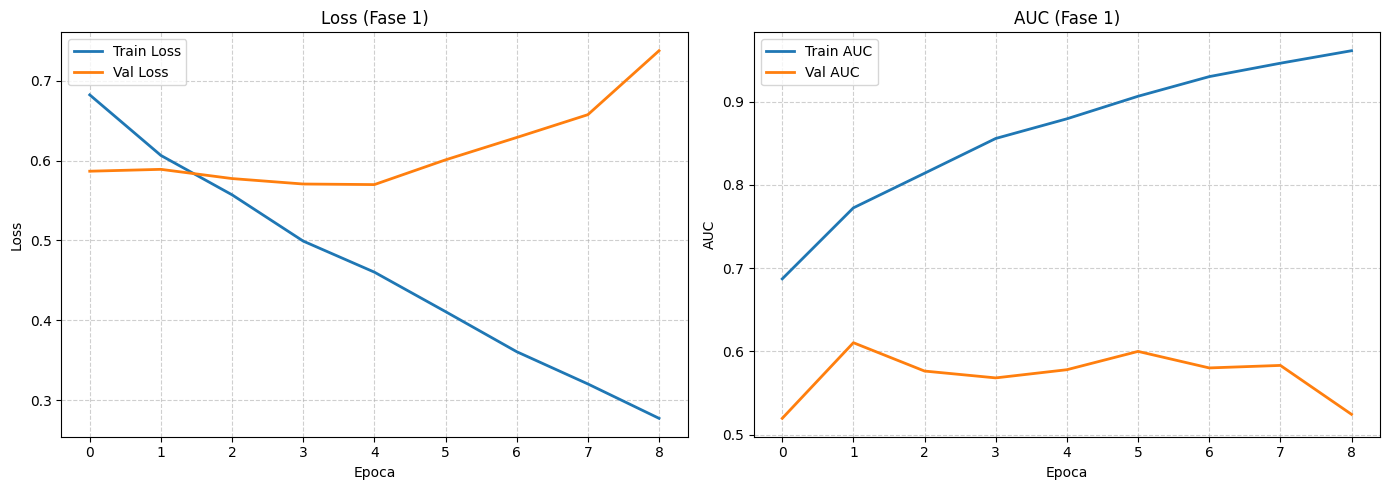

Grafico salvato in: /home/fede/Documenti/MammoDiffusion/experiments/exp_maxvit512_real_aug_synth_fromscratch_sdvae_partial/figures/training_history_fase1.png


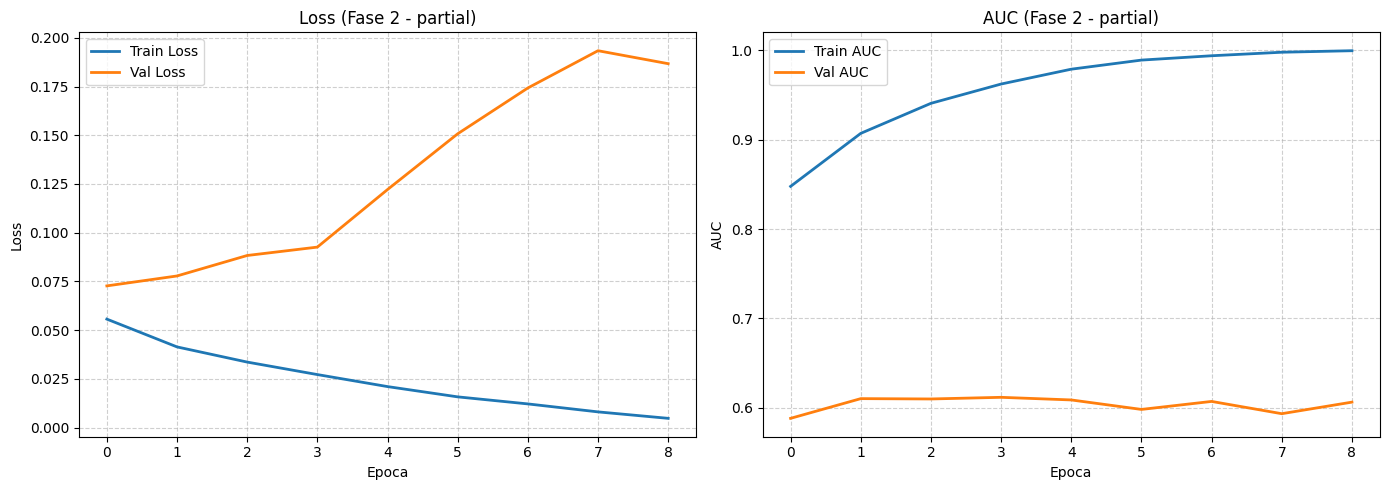

Grafico salvato in: /home/fede/Documenti/MammoDiffusion/experiments/exp_maxvit512_real_aug_synth_fromscratch_sdvae_partial/figures/training_history_fase2.png


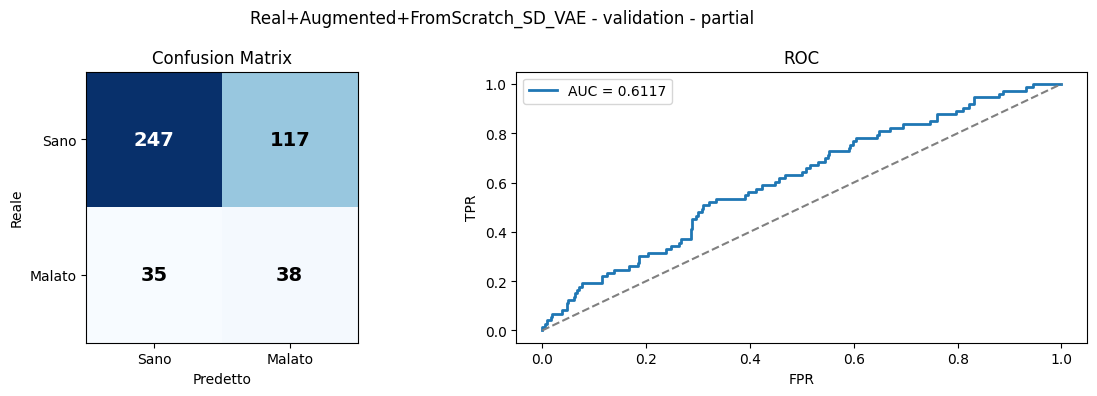

Figura salvata in: /home/fede/Documenti/MammoDiffusion/experiments/exp_maxvit512_real_aug_synth_fromscratch_sdvae_partial/figures/val_confusion_roc.png
Training completato. Miglior modello: /home/fede/Documenti/MammoDiffusion/experiments/exp_maxvit512_real_aug_synth_fromscratch_sdvae_partial/real_aug_synth_fromscratch_sdvae_maxvit512_partial_final_best.pt
{
  "roc_auc": 0.6117,
  "f1_malato": 0.3333,
  "recall_malato": 0.5205,
  "precision_malato": 0.2452
}


In [11]:
result = train_maxvit_experiment(
    df_train=df_train,
    df_val=df_val,
    output_dir=OUTPUT_DIR,
    checkpoint_prefix=CHECKPOINT_PREFIX,
    config_name=f'Real+Augmented+{SYNTHETIC_SOURCE_NAME}',
    fine_tune_mode=FINE_TUNE_MODE,
)

model = result['model']
val_threshold = result['threshold']
train_loader, val_loader, test_loader = make_loaders(df_train, df_val, df_test)

Metriche test salvate in: /home/fede/Documenti/MammoDiffusion/experiments/exp_maxvit512_real_aug_synth_fromscratch_sdvae_partial/test_metrics_maxvit512.json
{
  "roc_auc": 0.5938,
  "f1_malato": 0.2795,
  "recall_malato": 0.4384,
  "precision_malato": 0.2051
}


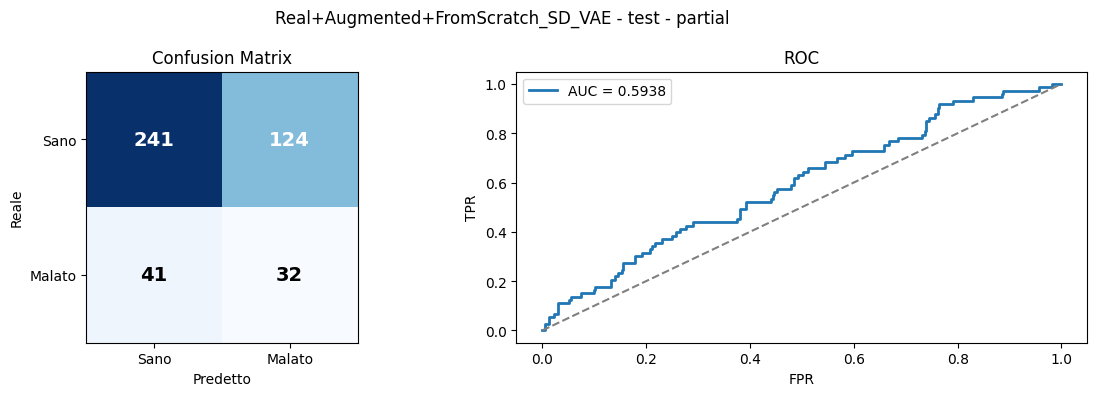

Figura salvata in: /home/fede/Documenti/MammoDiffusion/experiments/exp_maxvit512_real_aug_synth_fromscratch_sdvae_partial/figures/test_confusion_roc_maxvit512.png


In [12]:
test_true, test_prob = predict_probs(model, test_loader, DEVICE)
test_metrics, test_pred = metrics_from_probs(
    test_true,
    test_prob,
    val_threshold,
    'test',
    OUTPUT_DIR.name,
    f'Real+Augmented+{SYNTHETIC_SOURCE_NAME}',
)
test_metrics['fine_tune_mode'] = FINE_TUNE_MODE
test_metrics['checkpoint'] = str(result['checkpoint'])
with open(OUTPUT_DIR / 'test_metrics_maxvit512.json', 'w') as f:
    json.dump(test_metrics, f, indent=2, ensure_ascii=False)
print("Metriche test salvate in:", OUTPUT_DIR / 'test_metrics_maxvit512.json')
print(json.dumps({k: test_metrics[k] for k in ['roc_auc', 'f1_malato', 'recall_malato', 'precision_malato']}, indent=2))

save_confusion_roc(
    test_true,
    test_prob,
    test_pred,
    f'Real+Augmented+{SYNTHETIC_SOURCE_NAME} - test - {FINE_TUNE_MODE}',
    OUTPUT_DIR / 'figures' / 'test_confusion_roc_maxvit512.png',
)


{
  "Accuracy": {
    "mean": 0.5494794520547944,
    "std": 0.038991691884672997
  },
  "Precision": {
    "mean": 0.5639803275362667,
    "std": 0.050345360339695715
  },
  "Recall": {
    "mean": 0.4406164383561643,
    "std": 0.055040160025318655
  },
  "F1": {
    "mean": 0.4934733397621949,
    "std": 0.048844354530867024
  },
  "ROC_AUC": {
    "mean": 0.593720585475699,
    "std": 0.04590180548220288
  }
}


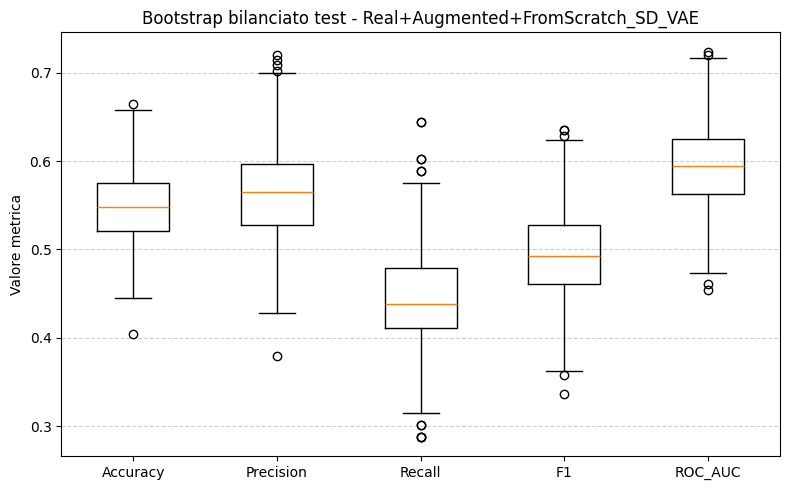

In [13]:
boot = bootstrap_balanced(test_true, test_prob, val_threshold, n_rounds=1000, seed=SEED)
boot_summary = {
    key: {'mean': float(np.mean(values)), 'std': float(np.std(values))}
    for key, values in boot.items()
}
with open(OUTPUT_DIR / 'bootstrap_balanced_test.json', 'w') as f:
    json.dump(boot_summary, f, indent=2, ensure_ascii=False)
print(json.dumps(boot_summary, indent=2))

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(list(boot.values()))
ax.set_xticklabels(list(boot.keys()))
ax.set_title(f'Bootstrap bilanciato test - Real+Augmented+{SYNTHETIC_SOURCE_NAME}')
ax.set_ylabel('Valore metrica')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'figures' / 'bootstrap_maxvit512.png', dpi=150, bbox_inches='tight')
plt.show()
